# Import données et librairies

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score,root_mean_squared_error

import tensorflow as tf
from tensorflow import keras
from keras import layers


In [2]:
donapp = pd.read_csv('donapp2.csv', sep='\t')
dontest = pd.read_csv('dontest.csv', sep=',')

On regarde s'il y a des valeurs manquantes et de quel type sont les données.

In [3]:
donapp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 16108 to 8518
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Pitch_angle                          10000 non-null  object
 1   Pitch_angle_std                      10000 non-null  object
 2   Hub_temperature                      10000 non-null  object
 3   Hub_temperature_std                  10000 non-null  object
 4   Generator_converter_speed            10000 non-null  object
 5   Generator_converter_speed_std        10000 non-null  object
 6   Generator_speed                      10000 non-null  object
 7   Generator_speed_std                  10000 non-null  object
 8   Generator_bearing_1_temperature      10000 non-null  object
 9   Generator_bearing_1_temperature_std  10000 non-null  object
 10  Generator_bearing_2_temperature      10000 non-null  object
 11  Generator_bearing_2_temperature_std  10000 

Il n'y a pas de valeurs manquantes mais toutes les colonnes sont de type object. On va donc remplacer les virgules par des points et convertir les variables en nombres.

In [4]:
for col in donapp.select_dtypes(include='object').columns:
    donapp[col] = donapp[col].str.replace(',', '.')

donapp=donapp.apply(pd.to_numeric)

Même chose pour dontest.

In [5]:
dontest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Pitch_angle                          5000 non-null   float64
 1   Pitch_angle_std                      5000 non-null   float64
 2   Hub_temperature                      5000 non-null   float64
 3   Hub_temperature_std                  5000 non-null   float64
 4   Generator_converter_speed            5000 non-null   float64
 5   Generator_converter_speed_std        5000 non-null   float64
 6   Generator_speed                      5000 non-null   float64
 7   Generator_speed_std                  5000 non-null   float64
 8   Generator_bearing_1_temperature      5000 non-null   float64
 9   Generator_bearing_1_temperature_std  5000 non-null   float64
 10  Generator_bearing_2_temperature      5000 non-null   float64
 11  Generator_bearing_2_temperatur

Pas de valeurs manquantes et les variables sont toutes numériques, pas de retraitement à faire.

On va maintenant regarder la distribution des variables ainsi que les corrélations entre variables.

In [6]:
donapp.describe()

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,Generator_bearing_2_temperature,Generator_bearing_2_temperature_std,Generator_stator_temperature,Generator_stator_temperature_std,Gearbox_bearing_1_temperature,Gearbox_bearing_1_temperature_std,Gearbox_bearing_2_temperature,Gearbox_bearing_2_temperature_std,Gearbox_inlet_temperature,Gearbox_inlet_temperature_std,Gearbox_oil_sump_temperature,Gearbox_oil_sump_temperature_std,Nacelle_angle,Nacelle_temperature_std,Absolute_wind_direction,Outdoor_temperature_std,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,12.117419,0.979728,19.916497,0.088934,1084.044392,63.293386,1084.658745,63.504628,39.780575,0.401288,37.758908,0.230659,57.453574,0.551648,56.783403,0.451427,59.872267,0.391782,48.824235,0.516821,52.543491,0.213041,178.858434,0.503967,178.642516,0.108753,49.966846,0.020024,10.311715,0.606116,31.181600,0.055619,178.857872,-0.102277,-0.100138,381.081990
std,26.374891,4.298048,6.855952,0.145753,592.004629,79.548122,593.131796,79.588486,7.832483,0.304838,7.923494,0.164699,11.612295,0.302533,12.464452,0.451245,13.282095,0.376743,9.440300,0.789801,8.967347,0.182899,96.788409,0.548343,96.140948,0.116789,1.206018,0.453138,5.650619,0.758032,7.199518,0.041180,96.787749,0.712100,0.687403,468.654577
min,-30.410000,0.000000,0.320000,0.000000,2.470000,0.010000,-0.040000,0.000000,-1.570000,0.000000,-2.840000,0.000000,-3.200000,0.000000,-4.300000,0.000000,-3.600000,0.000000,-5.890000,0.000000,-2.940000,0.000000,0.360000,0.000000,0.110000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.010000,0.000000,0.360000,-1.000000,-1.000000,-16.873000
25%,-1.010000,0.000000,15.000000,0.000000,926.669980,12.520000,927.020020,12.677500,37.980000,0.180000,36.200001,0.110000,58.230000,0.400000,52.980000,0.150000,54.650002,0.140000,45.930000,0.140000,50.900002,0.090000,80.099998,0.110000,81.140004,0.040000,49.990002,0.010000,8.800000,0.120000,28.780001,0.020000,80.099998,-0.797926,-0.777859,28.488250
50%,-1.000000,0.000000,20.000000,0.000000,1189.900050,38.545000,1190.639950,38.685000,41.669998,0.350000,39.540001,0.200000,60.669998,0.550000,60.504999,0.300000,64.500000,0.280000,51.155001,0.240000,55.790001,0.150000,199.730000,0.290000,198.195000,0.080000,50.000000,0.010000,11.310000,0.370000,32.759998,0.050000,199.730000,-0.236923,-0.162379,205.887994
75%,2.970000,0.000000,25.000000,0.140000,1571.600000,86.165003,1573.042500,86.300003,44.419998,0.530000,42.180000,0.300000,63.180000,0.690000,64.312498,0.590000,69.169998,0.530000,55.540001,0.470000,57.720001,0.270000,252.420000,0.720000,251.232503,0.122500,50.009998,0.010000,14.970000,0.820000,35.752499,0.090000,252.420000,0.631725,0.555933,551.950742
max,150.179990,64.790001,37.000000,0.750000,1802.340000,869.690000,1803.740000,872.190000,62.740002,1.950000,53.150002,2.740000,80.370003,2.380000,74.879997,6.840000,75.790001,7.760000,58.549999,6.770000,60.820000,1.910000,359.980010,3.580000,359.769990,1.560000,50.090000,24.650000,17.180000,8.300000,43.880001,0.390000,359.980010,1.000000,0.999998,2248.137000


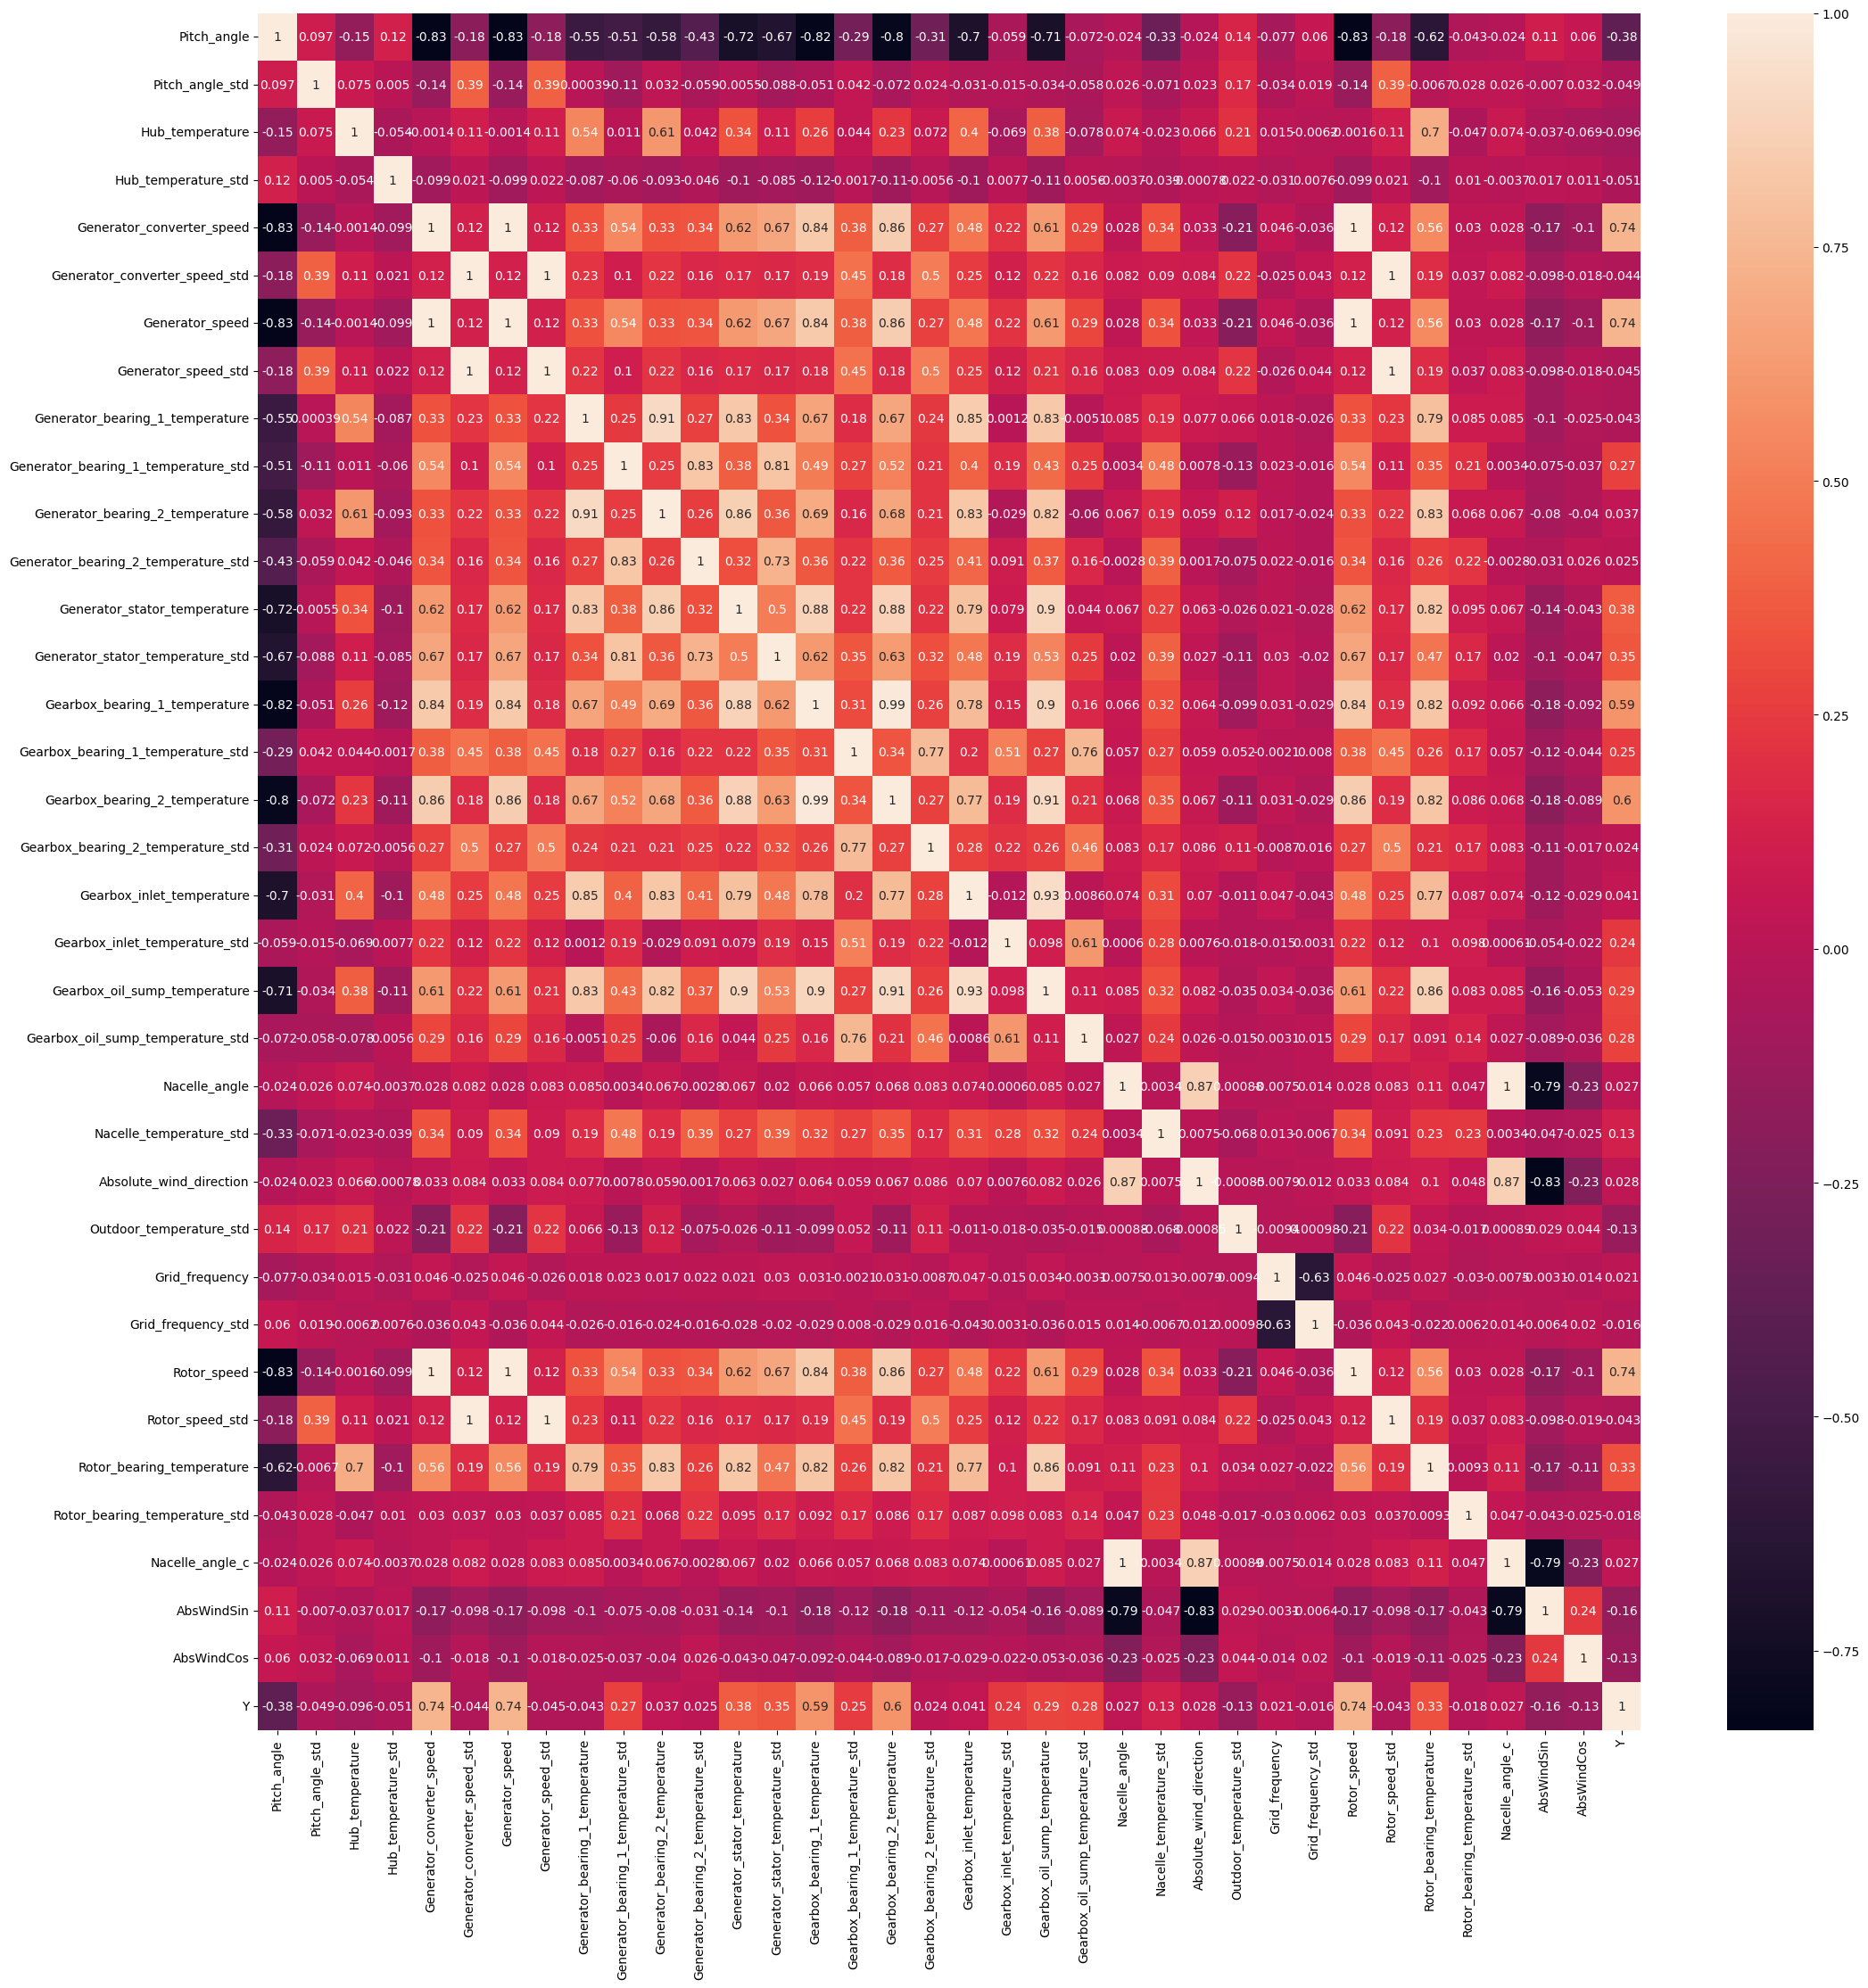

In [7]:
plt.figure(figsize=(25, 25))
sns.heatmap(donapp.corr(), annot=True)
plt.show()

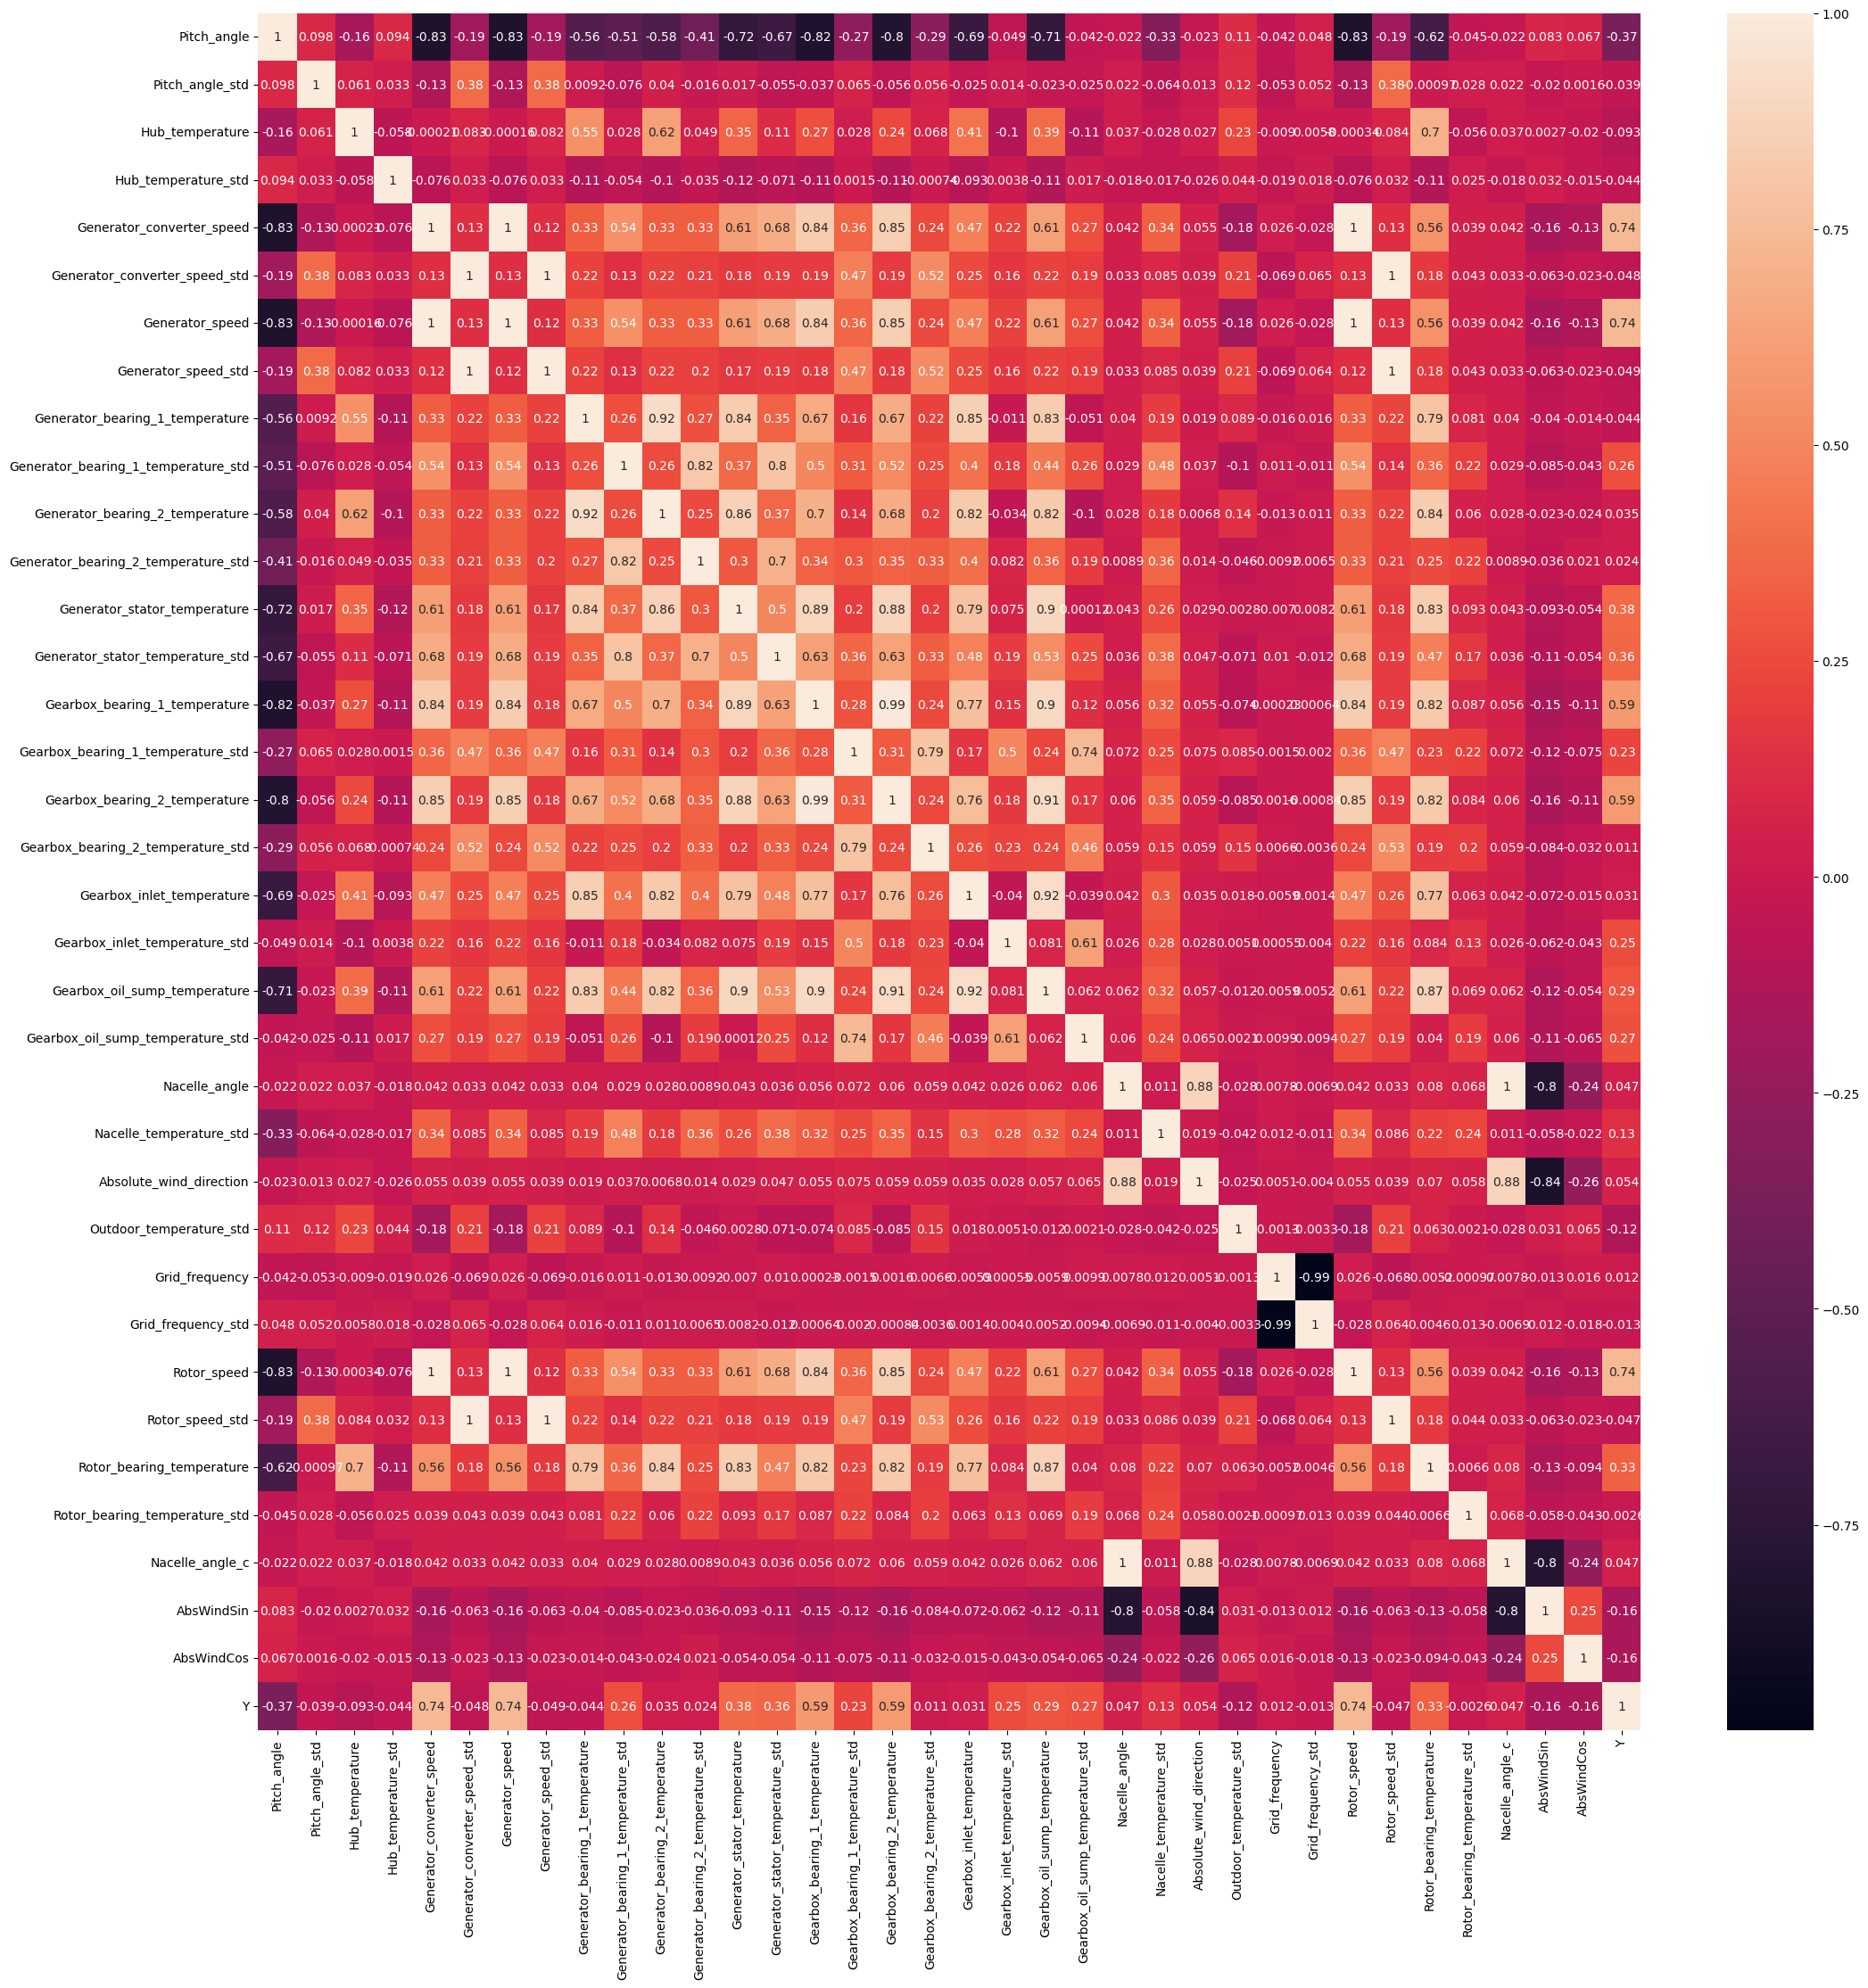

In [8]:
plt.figure(figsize=(25, 25))
sns.heatmap(dontest.corr(), annot=True)
plt.show()

Plusieurs variables sont entièrement corrélées : 
- Generator_converter_speed,generator_speed et rotor_speed
- Generator_converter_speed_std, generator_speed_std, rotor_speed_std
- Nacelle_angle et Nacelle_angle_c
Le même phénomène apparaît dans dontest.

On va donc enlever les variables generator_speed, rotor_speed, generator_speed_std, rotor_speed_std et Nacelle_angle_c des deux datasets.

In [9]:
donapp=donapp.drop(['Generator_speed', 'Generator_speed_std', 'Rotor_speed', 'Rotor_speed_std', 'Nacelle_angle_c'], axis=1)
dontest=dontest.drop(['Generator_speed', 'Generator_speed_std', 'Rotor_speed', 'Rotor_speed_std', 'Nacelle_angle_c'], axis=1)


On choisit de garder toutes les variables et toutes les lignes pour la suite.

# Modèles

C'est un problème de régression (Y numérique). Toutes les variables explicatives sont quantitatives.

Les données d'entraînement sont celles de donapp et les données de test sont celles de dontest.
Nous allons tester régression linéaire, Random Forest et Gradient Boosting.
Nous allons standardiser les données pour la régression linéaire.

La métrique utilisée est le MSE. On regardera aussi le R² mais ne pas utiliser pour comparer des modèles avec un nombre différent de variables explicatives.

In [10]:
X_train = donapp.drop(["Y"], axis=1)
y_train = donapp["Y"]
X_test = dontest.drop(['Y'], axis=1)
y_test=dontest['Y']

In [11]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),         
    columns=X_train.columns,               
    index=X_train.index                    
)
X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),         
    columns=X_test.columns,               
    index=X_test.index                    
)

## Régression linéaire

In [12]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_predict_lr = lr.predict(X_test_scaled)

mse_lr=mean_squared_error(y_test, y_predict_lr)
print('MSE : ',mse_lr)
print('R2 : ', r2_score(y_test, y_predict_lr))

resultats = []
resultats.append(['Régression linéaire', mse_lr])

MSE :  23097.599239159244
R2 :  0.8984839095215865


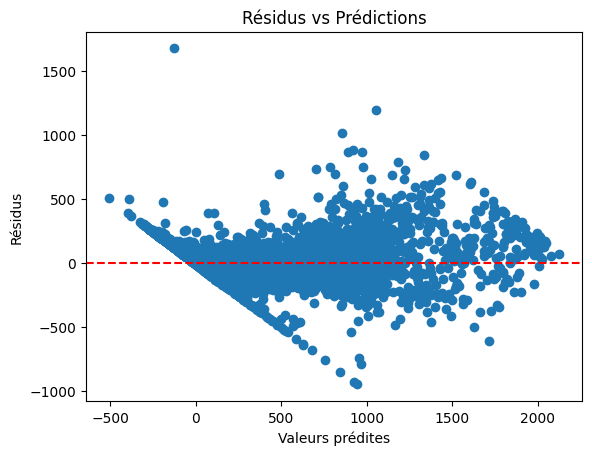

In [13]:
residuals = y_test - y_predict_lr
plt.scatter(y_predict_lr, residuals)
plt.axhline(0, color='red', linestyle='--')  # ligne zéro
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions")
plt.show()

Les résidus n'ont pas l'air de suivre une loi normale. On peut voir en haut à gauche un point qui a l'air aberrant.

Pour essayer d'améliorer le MSE, on teste Ridge et Lasso.

## Ridge et Lasso

In [14]:
kf_lasso = KFold(n_splits=5, shuffle=True, random_state=42)
alphas=[0.001, 0.01, 0.1, 1.0, 10]
lassocv = LassoCV(cv=kf_lasso, alphas=alphas)
lassocv.fit(X_train_scaled, y_train)

print("Meilleur alpha Lasso :", lassocv.alpha_)

y_predict_lasso = lassocv.predict(X_test_scaled)
mse_lasso=mean_squared_error(y_test, y_predict_lasso)

print("R2:", r2_score(y_test, y_predict_lasso))
print("MAE:", mse_lasso)

resultats.append(['Lasso', mse_lasso])

Meilleur alpha Lasso : 0.01
R2: 0.898467461462365
MAE: 23101.341608259278


In [15]:
grilleridge = lassocv.alphas_ * 100
ridgecv = RidgeCV(cv=kf_lasso, alphas=grilleridge)
ridgecv.fit(X_train_scaled, y_train)

print("Meilleur alpha Ridge :", ridgecv.alpha_)

y_predict_ridge = ridgecv.predict(X_test_scaled)
mse_ridge=mean_squared_error(y_test, y_predict_ridge)

print("R2:", r2_score(y_test, y_predict_ridge))
print("MAE:", mse_ridge)


resultats.append(['Ridge', mse_ridge])

Meilleur alpha Ridge : 0.1
R2: 0.8984786862053101
MAE: 23098.78768195174


Ridge et Lasso n'ont pas amélioré le MSE. Pour améliorer les modèles, on pourrait passer plus de temps à faire du feature engineering (transformations de variables, interactions etc).

## Random Forest

La seed est fixée à 42. On regarde ce que donne le modèle avec les paramètres par défaut, faute de temps on n'optimise pas les hyperparamètres.

In [16]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_predict_rf = rf.predict(X_test)
mse_rf=mean_squared_error(y_test, y_predict_rf)

print('MSE : ',mse_rf)
print('R2 : ', r2_score(y_test, y_predict_rf))

resultats.append(['Random Forest', mse_rf])

MSE :  2924.2642704508157
R2 :  0.9871475873666304


Le MSE est bien meilleur que pour les modèles linéaires.

## Gradient Boosting

La seed est fixée à 42. On regarde ce que donne le modèle avec les paramètres par défaut, faute de temps on n'optimise pas les hyperparamètres.

In [17]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_predict_gb = gb.predict(X_test)

mse_gb=mean_squared_error(y_test, y_predict_gb)

print('MSE : ',mse_gb)
print('R2 : ', r2_score(y_test, y_predict_gb))

resultats.append(['Gradient Boosting', mse_gb])

MSE :  3110.2065973063072
R2 :  0.9863303535978141


Le gradient boosting est meilleur que les modèles linéaires mais quand même moins bon que le Random Forest.

In [18]:
resultats

[['Régression linéaire', 23097.599239159244],
 ['Lasso', 23101.341608259278],
 ['Ridge', 23098.78768195174],
 ['Random Forest', 2924.2642704508157],
 ['Gradient Boosting', 3110.2065973063072]]

Parmi les modèles testés, le Random Forest est le meilleur, avec la MSE la plus faible.

# Clustering

On cherche à créer 3 ou 4 clusters. Pour cela on utilise une CAH.

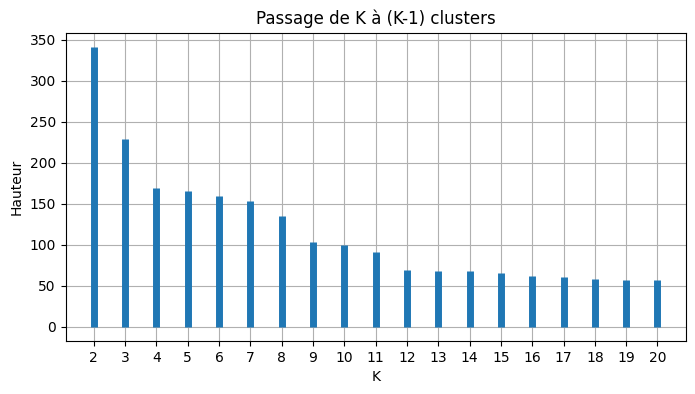

In [19]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
cah_model = AgglomerativeClustering(metric='euclidean', linkage='ward', distance_threshold=0, n_clusters=None)
cah_out = cah_model.fit(X_train_scaled)

k_max = 20

fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines(range(2, k_max+1), 0, np.flip(np.sort(cah_out.distances_))[0:k_max-1], linewidth=5)
ax.set_xticks(range(2, k_max+1))
ax.grid()
ax.set_xlabel('K')
ax.set_ylabel('Hauteur')
plt.title('Passage de K à (K-1) clusters')
plt.show()

On garde 3 clusters (méthode du coude). On crée la variable Cluster qui indique le numéro du cluster dans lequel se trouve l'individu et on récupère les y correspondants à chaque cluster.

In [20]:
cah_model = AgglomerativeClustering(metric='euclidean', linkage='ward', n_clusters=3)
labels = cah_model.fit_predict(X_train_scaled)

# Ajouter les labels au dataframe
X_train_scaled['Cluster'] = labels

In [56]:
X_train_scaled

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,Generator_bearing_2_temperature,Generator_bearing_2_temperature_std,Generator_stator_temperature,Generator_stator_temperature_std,Gearbox_bearing_1_temperature,Gearbox_bearing_1_temperature_std,Gearbox_bearing_2_temperature,Gearbox_bearing_2_temperature_std,Gearbox_inlet_temperature,Gearbox_inlet_temperature_std,Gearbox_oil_sump_temperature,Gearbox_oil_sump_temperature_std,Nacelle_angle,Nacelle_temperature_std,Absolute_wind_direction,Outdoor_temperature_std,Grid_frequency,Grid_frequency_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,AbsWindSin,AbsWindCos,Cluster
16108,-0.497370,-0.227959,1.179108,-0.335749,0.797678,-0.359843,1.045624,-0.397896,0.604699,-0.793357,0.610283,0.259000,0.577399,-0.446403,0.676714,-0.429444,0.250615,-0.515119,0.514839,-0.399372,0.948008,-0.718505,1.044118,-0.160580,0.044076,-0.022122,1.155468,-1.107846,-1.243366,0.373769,0
15683,-0.497370,-0.227959,0.015098,0.693440,0.249547,-0.408495,0.610236,-0.463508,0.342176,-0.125441,0.601671,-0.005448,0.412120,-0.668023,0.459117,-0.801068,0.740031,-0.401160,0.559448,-0.454049,1.791953,2.637229,1.825406,-0.674354,0.019201,-0.022122,0.202579,-0.379303,0.000008,1.592878,0
7800,-0.497370,-0.227959,-0.495433,2.271529,0.641422,0.480194,-0.272031,1.111176,0.290428,0.360317,0.242550,2.804305,0.737061,1.658989,0.730172,2.649730,0.790879,-0.059285,0.597365,-0.125983,0.113569,0.849936,0.137071,-0.588725,0.010907,-0.022122,0.440107,0.349239,-0.144033,-1.278292,0
12843,-0.497749,-0.227959,-1.592345,-0.610199,-0.152565,-0.583869,-2.312355,-1.054015,-2.790437,-0.611198,-2.716530,-0.468230,-1.178884,0.816832,-1.385563,2.384284,-1.508950,0.029349,-1.837145,0.147406,-1.088495,-0.846168,-1.159320,-0.588725,0.002616,-0.022122,-2.129638,2.292019,1.438174,0.709684,1
10051,1.246421,-0.227959,1.324974,-0.610199,-1.826706,-0.795576,0.823461,-1.086821,0.724602,-1.339835,-0.086428,-1.559076,-0.543445,-0.623699,-0.566375,-0.774524,0.144681,-0.388498,0.162432,-0.071305,-1.473994,-0.882644,-1.232029,0.952597,0.019201,-0.022122,0.394268,0.592086,1.362296,0.868692,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4619,-0.497749,-0.227959,0.595644,-0.610199,1.076896,0.566561,0.316572,0.750311,0.419166,-0.125441,0.376898,0.622615,0.646398,0.351430,0.704573,-0.110909,0.162690,-0.388498,0.405548,0.092728,-1.315290,-0.335513,-1.373911,0.010678,0.052367,-0.022122,1.073514,-0.864998,1.163339,1.146012,0
9505,1.246421,-0.227959,0.449778,-0.610199,-1.826672,-0.795324,0.035677,-1.119627,0.579456,-1.096956,0.164181,-1.360740,-0.540236,-0.490727,-0.493340,-0.429444,-0.040704,-0.413822,0.117823,0.584828,1.451812,0.102191,0.391190,2.408290,0.035782,-0.022122,0.134516,2.049171,-0.686781,-1.027551,1
5317,1.246042,-0.227959,-0.717150,-0.610199,-1.614096,4.102585,0.224643,-0.037031,0.901301,-0.611198,0.606838,-0.732678,-0.252202,0.994129,-0.246379,0.658885,0.349134,0.168632,0.295142,-0.454049,-0.657533,3.859154,-0.541342,0.267565,0.027492,-0.022122,-0.486390,0.834934,1.271085,-0.721719,1
10139,-0.497370,-0.227959,1.908438,-0.610199,1.205550,-0.711220,0.703443,0.126998,0.787709,-0.854077,0.655926,-0.071560,0.798037,0.240620,0.843865,-0.668345,0.026035,0.042011,0.465770,0.092728,1.655876,1.087026,1.577008,-0.160580,0.019201,-0.022122,1.405498,-1.107846,-0.553235,1.408759,0


In [57]:
clusters = X_train_scaled['Cluster'].unique()

y_by_cluster = {} 

for c in clusters:
    idx = X_train_scaled['Cluster'] == c         
    y_by_cluster[c] = y_train[idx] 

In [58]:
X_train_scaled_0 = X_train_scaled[X_train_scaled['Cluster']==0]
y_train_0 = y_by_cluster[0]
X_train_scaled_1 = X_train_scaled[X_train_scaled['Cluster']==1]
y_train_1 = y_by_cluster[1]
X_train_scaled_2 = X_train_scaled[X_train_scaled['Cluster']==2]
y_train_2 = y_by_cluster[2]

In [64]:
print(X_train_scaled_0.shape)
print(X_train_scaled_1.shape)
print(X_train_scaled_2.shape)

(7576, 31)
(2076, 31)
(348, 31)


Le nombre d'observations dans les clusters n'est pas homogène.

Il faut également avoir les clusters pour les données de test. AgglomerativeClustering ne permet pas de prédire de nouveaux clusters directement. On doit entraîner un classifieur sur les clusters obtenus à partir de X_train_scaled et Cluster (par exemple RandomForestClassifier).

In [24]:
from sklearn.ensemble import RandomForestClassifier

# X_train avec colonne Cluster
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled.drop('Cluster', axis=1), X_train_scaled['Cluster'])

# Prédire le cluster pour X_test
cluster_test = clf.predict(X_test_scaled)


In [29]:
cluster_test=pd.DataFrame(cluster_test)
cluster_test.columns=['Cluster']

In [43]:
X_test_scaled_cluster=pd.concat([X_test_scaled, pd.DataFrame(cluster_test)], axis=1)

In [44]:
X_test_scaled_cluster

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,Generator_bearing_2_temperature,Generator_bearing_2_temperature_std,Generator_stator_temperature,Generator_stator_temperature_std,Gearbox_bearing_1_temperature,Gearbox_bearing_1_temperature_std,Gearbox_bearing_2_temperature,Gearbox_bearing_2_temperature_std,Gearbox_inlet_temperature,Gearbox_inlet_temperature_std,Gearbox_oil_sump_temperature,Gearbox_oil_sump_temperature_std,Nacelle_angle,Nacelle_temperature_std,Absolute_wind_direction,Outdoor_temperature_std,Grid_frequency,Grid_frequency_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,AbsWindSin,AbsWindCos,Cluster
0,-0.500819,-0.223721,0.149590,0.974196,0.573107,0.003117,0.051589,-0.514850,0.034495,-0.158707,0.080523,0.219318,0.439679,0.589847,0.484689,0.145395,0.686637,-0.064882,0.499162,0.590146,0.653007,1.802113,0.578175,-0.330116,0.088254,-0.019069,0.608513,-0.834603,-0.967796,-0.703839,0
1,2.934994,-0.223721,0.300974,-0.614693,-1.820886,-0.782117,0.014252,-1.021625,0.188372,-1.135288,-0.091925,-1.425750,-0.759568,-0.446100,-0.624421,-0.514016,-0.276618,-0.360499,-0.020031,0.100199,-1.047367,-0.838113,-1.512631,-0.678286,0.015767,-0.019069,-0.081181,1.061899,0.963937,1.369574,1
2,3.009382,-0.223721,0.888870,-0.614693,-1.821105,-0.782117,-0.220978,-0.954055,-0.896152,-0.646997,-0.792599,-1.425750,-1.689384,-0.640340,-1.441069,-0.615463,-1.968137,1.156146,-1.136744,0.154638,-1.323086,-0.657275,0.592935,-0.243074,0.044763,-0.019069,-0.441796,-0.360478,-0.988131,-0.675075,1
3,-0.500441,-0.223721,0.300974,-0.476529,0.613193,0.077777,0.335358,-0.683775,0.352096,1.123056,-0.007375,-0.049265,-0.217509,4.021420,-0.068741,6.080090,0.031412,0.282147,-0.224799,2.386615,1.066587,-0.313684,1.173439,1.410729,-0.013228,-0.019069,-0.380094,3.669590,-1.168571,0.660377,0
4,-0.500441,-0.223721,-1.021793,-0.614693,-0.152891,-0.074152,-0.537106,-0.818915,-0.331117,-0.891143,0.037829,-0.720721,-0.467751,-0.230278,-0.550931,-0.082863,-0.186644,-0.553292,-0.448589,-0.716378,-1.185227,0.264995,-1.062651,-0.068990,0.030262,-0.019069,-0.718770,-0.834603,1.535502,0.487992,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-0.500819,-0.223721,-1.315741,-0.614693,-0.188680,0.338900,0.514581,-0.278355,0.073887,-1.013215,0.522525,-0.620002,0.119080,-0.554011,0.120235,-0.108225,0.541620,-0.489028,0.348104,-0.716378,0.446165,-0.693443,0.339478,-0.939412,0.044763,0.010322,-0.360898,-0.360478,-0.555230,-1.085451,0
4996,-0.500441,-0.223721,-1.315741,-0.614693,0.457769,0.695802,-0.103986,-0.683775,-0.092300,-0.280779,0.006856,-0.317847,0.044727,1.474718,0.409698,1.109149,-0.085026,0.166471,0.338034,1.678915,-0.231619,-0.729610,-0.212454,-0.504201,-0.042225,-0.019069,-0.040046,-0.123415,0.684785,-1.181828,0
4997,-0.500819,-0.223721,-1.168767,-0.614693,0.622005,0.465860,0.244502,-0.109430,-0.280645,-0.463888,0.201906,-0.149983,0.251797,0.525100,0.318960,0.779444,0.267462,-0.244822,0.050463,0.372392,0.802382,-0.603024,0.761309,0.540306,0.015767,-0.019069,-0.526808,1.061899,-1.168983,-0.315619,0
4998,-0.500441,-0.223721,-0.286922,-0.614693,0.020681,-0.505962,0.723673,0.498701,0.035726,-0.280779,0.237902,-0.452138,-0.255885,-0.187114,-0.408449,0.475100,-0.282969,-0.437616,-0.541462,-0.171993,-0.714180,-0.603024,-0.628274,-0.591243,0.102755,-0.019069,-0.713286,-0.360478,1.396092,-0.528267,0


In [45]:
X_test_scaled_0 = X_test_scaled_cluster[X_test_scaled_cluster['Cluster']==0]
X_test_scaled_1 = X_test_scaled_cluster[X_test_scaled_cluster['Cluster']==1]
X_test_scaled_2 = X_test_scaled_cluster[X_test_scaled_cluster['Cluster']==2]

clusters = X_test_scaled_cluster['Cluster'].unique()

y_test_by_cluster = {} 

for c in clusters:
    idx = X_test_scaled_cluster['Cluster'] == c         
    y_test_by_cluster[c] = y_test[idx] 

y_test_0 = y_test_by_cluster[0]
y_test_1 = y_test_by_cluster[1]
y_test_2 = y_test_by_cluster[2]

In [68]:
print(X_test_scaled_0.shape)
print(X_test_scaled_1.shape)
print(X_test_scaled_2.shape)

(3791, 31)
(1021, 31)
(188, 31)


Nous allons maintenant pouvoir entraîner nos modèles sur chaque cluster.

## Régression Linéaire

In [48]:
lr = LinearRegression()
lr.fit(X_train_scaled_0, y_train_0)
y_predict_lr_0 = lr.predict(X_test_scaled_0)

mse_lr_0=mean_squared_error(y_test_0, y_predict_lr_0)
print('MSE : ',mse_lr_0)
print('R2 : ', r2_score(y_test_0, y_predict_lr_0))

lr.fit(X_train_scaled_1, y_train_1)
y_predict_lr_1 = lr.predict(X_test_scaled_1)

mse_lr_1=mean_squared_error(y_test_1, y_predict_lr_1)
print('MSE : ',mse_lr_1)
print('R2 : ', r2_score(y_test_1, y_predict_lr_1))

lr.fit(X_train_scaled_2, y_train_2)
y_predict_lr_2 = lr.predict(X_test_scaled_2)

mse_lr_2=mean_squared_error(y_test_2, y_predict_lr_2)
print('MSE : ',mse_lr_2)
print('R2 : ', r2_score(y_test_2, y_predict_lr_2))


resultats.append([['Régression linéaire - Cluster 0', mse_lr_0],
                 ['Régression linéaire - Cluster 1', mse_lr_1],
                 ['Régression linéaire - Cluster 2', mse_lr_2]])

MSE :  10108.61778177451
R2 :  0.9576732284052378
MSE :  3741.914575876067
R2 :  0.34922083749262123
MSE :  1.318839452027316
R2 :  0.7428290115051706


In [49]:
resultats

[['Régression linéaire', 23097.599239159244],
 ['Lasso', 23101.341608259278],
 ['Ridge', 23098.78768195174],
 ['Random Forest', 2924.2642704508157],
 ['Gradient Boosting', 3110.2065973063072],
 [['Régression linéaire - Cluster 0', 10108.61778177451],
  ['Régression linéaire - Cluster 1', 3741.914575876067],
  ['Régression linéaire - Cluster 2', 1.318839452027316]]]

## Random Forest

In [50]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled_0, y_train_0)

y_predict_rf_0 = rf.predict(X_test_scaled_0)
mse_rf_0=mean_squared_error(y_test_0, y_predict_rf_0)

print('MSE : ',mse_rf_0)
print('R2 : ', r2_score(y_test_0, y_predict_rf_0))

rf.fit(X_train_scaled_1, y_train_1)

y_predict_rf_1 = rf.predict(X_test_scaled_1)
mse_rf_1=mean_squared_error(y_test_1, y_predict_rf_1)

print('MSE : ',mse_rf_1)
print('R2 : ', r2_score(y_test_1, y_predict_rf_1))

rf.fit(X_train_scaled_2, y_train_2)

y_predict_rf_2 = rf.predict(X_test_scaled_2)
mse_rf_2=mean_squared_error(y_test_2, y_predict_rf_2)

print('MSE : ',mse_rf_2)
print('R2 : ', r2_score(y_test_2, y_predict_rf_2))


resultats.append([['Random Forest - Cluster 0', mse_rf_0],
                  ['Random Forest - Cluster 1', mse_rf_1],
                  ['Random Forest - Cluster 2', mse_rf_2]])

MSE :  6538.240371777879
R2 :  0.9726231011180526
MSE :  2436.08111420555
R2 :  0.576326290951855
MSE :  0.9578550612307997
R2 :  0.8132202274106688


In [51]:
resultats

[['Régression linéaire', 23097.599239159244],
 ['Lasso', 23101.341608259278],
 ['Ridge', 23098.78768195174],
 ['Random Forest', 2924.2642704508157],
 ['Gradient Boosting', 3110.2065973063072],
 [['Régression linéaire - Cluster 0', 10108.61778177451],
  ['Régression linéaire - Cluster 1', 3741.914575876067],
  ['Régression linéaire - Cluster 2', 1.318839452027316]],
 [['Random Forest - Cluster 0', 6538.240371777879],
  ['Random Forest - Cluster 1', 2436.08111420555],
  ['Random Forest - Cluster 2', 0.9578550612307997]]]

## Gradient Boosting

In [52]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_scaled_0, y_train_0)
y_predict_gb_0 = gb.predict(X_test_scaled_0)

mse_gb_0=mean_squared_error(y_test_0, y_predict_gb_0)

print('MSE : ',mse_gb_0)
print('R2 : ', r2_score(y_test_0, y_predict_gb_0))

gb.fit(X_train_scaled_1, y_train_1)
y_predict_gb_1 = gb.predict(X_test_scaled_1)

mse_gb_1=mean_squared_error(y_test_1, y_predict_gb_1)

print('MSE : ',mse_gb_1)
print('R2 : ', r2_score(y_test_1, y_predict_gb_1))

gb.fit(X_train_scaled_2, y_train_2)
y_predict_gb_2 = gb.predict(X_test_scaled_2)

mse_gb_2=mean_squared_error(y_test_2, y_predict_gb_2)

print('MSE : ',mse_gb_2)
print('R2 : ', r2_score(y_test_2, y_predict_gb_2))

resultats.append([['Gradient Boosting - Cluster 0', mse_gb_0],
                  ['Gradient Boosting - Cluster 1', mse_gb_1],
                  ['Gradient Boosting - Cluster 2', mse_gb_2]])

MSE :  5692.653813153235
R2 :  0.9761637384141859
MSE :  1885.7111944031474
R2 :  0.6720444769808359
MSE :  0.9611017725786654
R2 :  0.8125871253561281


In [53]:
resultats

[['Régression linéaire', 23097.599239159244],
 ['Lasso', 23101.341608259278],
 ['Ridge', 23098.78768195174],
 ['Random Forest', 2924.2642704508157],
 ['Gradient Boosting', 3110.2065973063072],
 [['Régression linéaire - Cluster 0', 10108.61778177451],
  ['Régression linéaire - Cluster 1', 3741.914575876067],
  ['Régression linéaire - Cluster 2', 1.318839452027316]],
 [['Random Forest - Cluster 0', 6538.240371777879],
  ['Random Forest - Cluster 1', 2436.08111420555],
  ['Random Forest - Cluster 2', 0.9578550612307997]],
 [['Gradient Boosting - Cluster 0', 5692.653813153235],
  ['Gradient Boosting - Cluster 1', 1885.7111944031474],
  ['Gradient Boosting - Cluster 2', 0.9611017725786654]]]

On voit que les résultats selon les clusters ne sont pas les mêmes. Pour les clusters 0 et 1, le Gradient Boosting Regressor est meilleur tandis que le Random Forest est meilleur pour le cluster 2.